In [1]:
# Load necessary library
library(fs)
library("ggplot2")
library("tidyverse")


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [10]:
# Define the base directory for the beta directories
beta_dir1 <- "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_beta"

# List directories in beta_dir1 that are exactly two levels deep
beta_subdirs1 <- list.dirs(beta_dir1, recursive = TRUE, full.names = TRUE)
beta_subdirs1 <- beta_subdirs1[sapply(strsplit(beta_subdirs1, "/"), length) == length(strsplit(beta_dir1, "/")[[1]]) + 2]

# Initialize a list to store beta directories categorized by mutation rate
beta_dirs_by_mutation_rate <- list()

# Loop through each beta directory and categorize based on mutation rate
for (beta_dir in beta_subdirs1) {
  # Extract the second-to-last directory as the mutation rate identifier
  mutation_rate_dir <- basename(dirname(beta_dir))
  
  # Store the directories under the mutation rate
  if (!is.null(beta_dirs_by_mutation_rate[[mutation_rate_dir]])) {
    beta_dirs_by_mutation_rate[[mutation_rate_dir]] <- c(beta_dirs_by_mutation_rate[[mutation_rate_dir]], beta_dir)
  } else {
    beta_dirs_by_mutation_rate[[mutation_rate_dir]] <- list(beta_dir)
  }
}

# Format the output for better readability
formatted_beta_dirs <- lapply(names(beta_dirs_by_mutation_rate), function(mutation_rate) {
  list(
    mutation_rate = mutation_rate,
    beta_dirs = beta_dirs_by_mutation_rate[[mutation_rate]]
  )
})

# Display the categorized beta directories
print("Beta Directories Categorized by Mutation Rate:")
print(formatted_beta_dirs)


[1] "Beta Directories Categorized by Mutation Rate:"
[[1]]
[[1]]$mutation_rate
[1] "m1e-10_free_r"

[[1]]$beta_dirs
[[1]]$beta_dirs[[1]]
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_beta/m1e-10_free_r/alpha1.3"

[[1]]$beta_dirs[[2]]
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_beta/m1e-10_free_r/alpha1.5"

[[1]]$beta_dirs[[3]]
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_beta/m1e-10_free_r/alpha1.7"

[[1]]$beta_dirs[[4]]
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_beta/m1e-10_free_r/alpha1.9"



[[2]]
[[2]]$mutation_rate
[1] "m1e-10"

[[2]]$beta_dirs
[[2]]$beta_dirs[[1]]
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_beta/m1e-10

In [11]:
# Initialize a list to store the paths of .rds files from beta directories
rds_files_list <- list()

# Loop through each formatted beta directory group
for (i in seq_along(formatted_beta_dirs)) {
  # Get the mutation rate (beta directory identifier)
  mutation_rate <- formatted_beta_dirs[[i]]$mutation_rate
  
  # Get the beta directories
  beta_dirs <- formatted_beta_dirs[[i]]$beta_dirs
  
  # Collect the .rds files from each beta directory
  rds_files_beta <- unlist(lapply(beta_dirs, function(beta_dir) {
    list.files(path = beta_dir, pattern = "\\.rds$", full.names = TRUE)
  }))
  
  # Store the results in the list
  rds_files_list[[mutation_rate]] <- rds_files_beta
}

# Print the list of .rds files, categorized by mutation rate
print(rds_files_list)


$`m1e-10_free_r`
 [1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_beta/m1e-10_free_r/alpha1.5/Beta_bottleneck_rep5_m1e-10_ratio999.9999999999999_rs1525230.vcf.rds"
 [2] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_beta/m1e-10_free_r/alpha1.5/Beta_bottleneck_rep7_m1e-10_ratio999.9999999999999_rs1525232.vcf.rds"
 [3] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_beta/m1e-10_free_r/alpha1.7/Beta_bottleneck_rep0_m1e-10_ratio999.9999999999999_rs1525225.vcf.rds"
 [4] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_beta/m1e-10_free_r/alpha1.7/Beta_bottleneck_rep2_m1e-10_ratio999.9999999999999_rs1525227.vcf.rds"
 [5] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6h

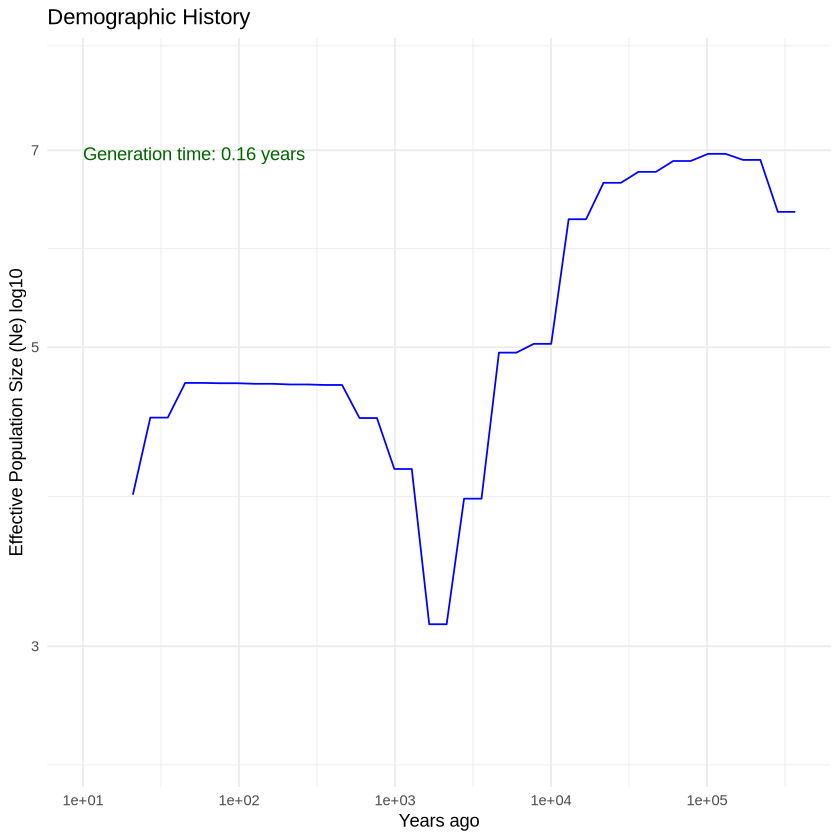

In [4]:

# Provided demography data
demography_data <- data.frame(
  years_ago = c(20.90991, 27.04340, 34.97601, 45.23550, 58.50439,
                75.66543, 97.86030, 126.56557, 163.69094, 211.70625,
                273.80586, 354.12109, 457.99511, 592.33841, 766.08851,
                990.80457, 1281.43640, 1657.31899, 2143.45890, 2772.19779,
                3585.36410, 4637.05576, 5997.23919, 7756.40403, 10031.58311,
                12974.13845, 16779.83093, 21701.84380, 28067.62632, 36300.67815,
                46948.72375, 60720.15108, 78531.13893, 101566.60798, 131359.05066,
                169890.48403, 219724.30843, 284175.84417, 367532.89150),
  Ne_log10 = c(3.886466, 4.433363, 4.433363, 4.704220, 4.704220,
               4.701291, 4.701291, 4.696954, 4.696954, 4.691536,
               4.691536, 4.687589, 4.687589, 4.430142, 4.430142,
               4.060712, 4.060712, 3.114804, 3.114804, 3.860018,
               3.860018, 4.953656, 4.953656, 5.028866, 5.028866,
               6.221847, 6.221847, 6.621246, 6.621246, 6.746056,
               6.746056, 6.872533, 6.872533, 6.957109, 6.957109,
               6.885372, 6.885372, 6.300497, 6.300497)
)

# Convert years_ago to generations_ago (assuming generation time of 0.16 years)

# Convert Ne_log10 to actual Ne values

# Plotting using ggplot2
ggplot(demography_data, aes(x = years_ago, y = Ne_log10)) +
  geom_line(color = "blue") +
  scale_x_log10() +
  scale_y_log10(limits = c(2.5, 8)) +  # Adjusting y-axis limits
  labs(title = "Demographic History",
       x = "Years ago",
       y = "Effective Population Size (Ne) log10") +
  theme_minimal() +
  annotate("text", x = 10, y = max(demography_data$Ne_log10, na.rm = TRUE), 
           label = "Generation time: 0.16 years", hjust = 0, color = "darkgreen")


In [14]:
Ne

[1] 143698

In [19]:
# Constants
mu <- 1e-07
gen_times <-25

# Initialize a list to store individual data frames with hierarchical structure
individual_data_frames <- vector("list", length(rds_files_list))


# Initialize sub-lists for 'kingman' and 'beta' within each main entry
individual_data_frames[[1]] <- list()
  

  # Process 'beta' files
  for (j in seq_along(rds_files_list[[3]])) {
    beta_dir <- rds_files_list[[3]][j]
    #split path
    path_components <- unlist(strsplit(beta_dir, "/"))
    # Extract the second last component
    second_last_component <- path_components[length(path_components) - 1]
    if (file.exists(beta_dir)) {
      data_esmc <- readRDS(beta_dir)  # Read the .rds file

      # Perform calculations
      Ne_t <- data_esmc$Xi
      Ne <- mean(data_esmc$mu / mu)
       alpha<-data_esmc$alpha
      # Calculate years ago and log10 of Ne
      data_esmc$years_ago <- data_esmc$Tc * Ne * gen_times
      data_esmc$Ne <- log10(Ne_t * Ne)
      
      # Create a unique label using both j and file_base_name
      file_base_name <- basename(beta_dir)
      label <- paste0(j, "_",file_base_name)
      # Store the results in a data frame using the unique label
      individual_data_frames[[1]][[label]] <- data.frame(
        years_ago = data_esmc$years_ago,
        Ne = data_esmc$Ne,
        alpha_sim=as.character(second_last_component),
        alpha_inf=alpha
      )
    } else {
      warning(paste("Beta directory does not exist:", beta_dir))
    }
}



In [20]:
# Create a color palette for the alpha values
alpha_values <- unique(unlist(lapply(individual_data_frames[[1]], function(df) df$alpha_sim)))
colors <- rainbow(length(alpha_values))  # Generate colors for each alpha
alpha_values


[1] "alpha1.3" "alpha1.5" "alpha1.7" "alpha1.9"

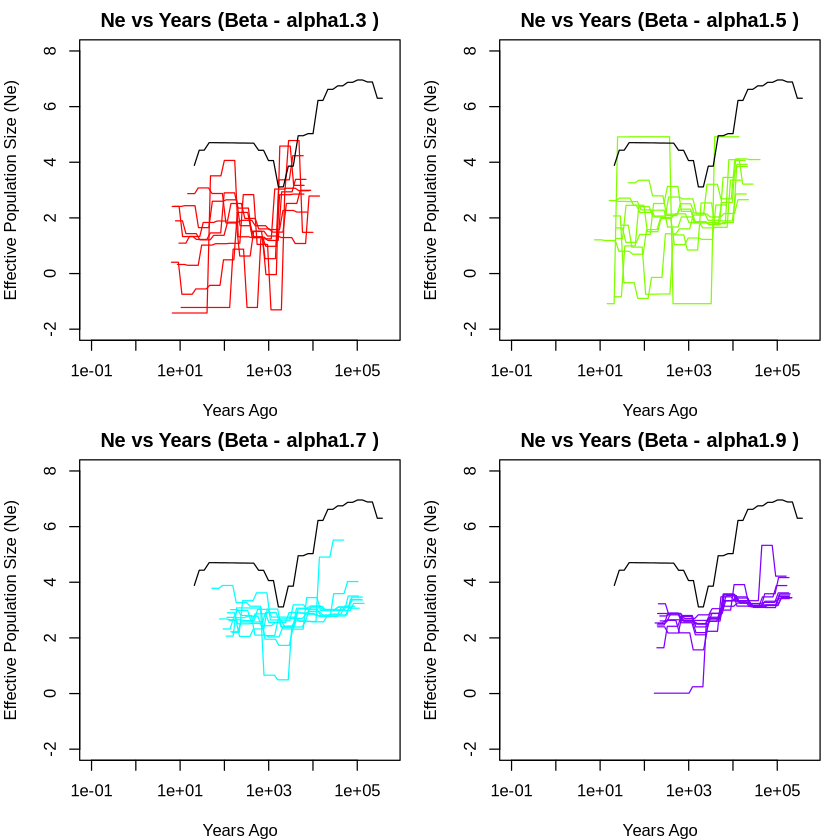

In [21]:
# Define the number of rows and columns for subplots based on the number of alpha values
num_alphas <- length(alpha_values)
rows <- ceiling(sqrt(num_alphas))  # Number of rows for the plot grid
cols <- ceiling(num_alphas / rows) # Number of columns for the plot grid

# Set up layout for multiple subplots
par(mfrow = c(rows, cols), mar = c(4, 4, 2, 1), bg = "white")  # White background for the plots

# Check that alpha_values and colors are compatible
if (length(alpha_values) != length(colors)) {
  stop("Length of alpha_values does not match the length of colors.")
}

# Loop over each alpha value and create individual plots
for (alpha in alpha_values) {
  
  # Set up an empty plot for the current alpha
  plot(NULL, xlim = c(0.1, 500000), ylim = c(-2, 8),
       xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
       main = paste("Ne vs Years (Beta -", alpha, ")"),
       log = "x", col = "black")
  
  # Filter Beta data frames by the current alpha
  beta_lines <- lapply(individual_data_frames[[1]], function(df) {
    if (!is.null(df) && df$alpha_sim[1] == alpha) {  # Ensure df is not NULL
      return(df)
    } else {
      return(NULL)
    }
  })

  beta_lines <- Filter(Negate(is.null), beta_lines)  # Remove NULL entries
  
  # If beta_lines is empty, skip the plot for this alpha
  if (length(beta_lines) > 0) {
    # Plot each line for the current alpha
    for (i in seq_along(beta_lines)) {
      lines(beta_lines[[i]]$years_ago, beta_lines[[i]]$Ne, 
            type = "l", lty = 1, col = colors[which(alpha_values == alpha)])
    }
  } else {
    message("No data found for alpha: ", alpha)
  }

  # Plot the overall demography line in black for each subplot
  lines(demography_data$years_ago, demography_data$Ne, 
        type = "l", lty = 1, col = "black")
}

# Reset layout to default for any further plots
par(mfrow = c(1, 1), bg = "white")



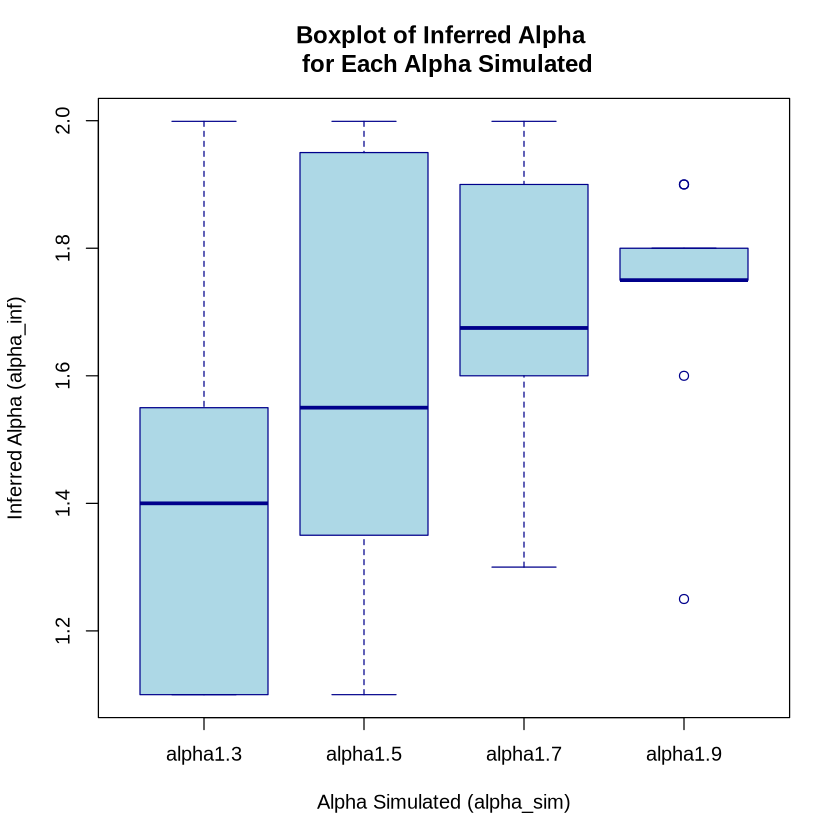

In [15]:
# Initialize a list to store alpha_inf values grouped by alpha_sim
alpha_data <- list()

# Loop through each entry in individual_data_frames to extract alpha_sim and alpha_inf
for (entry in individual_data_frames[[1]]) {
  if (!is.null(entry$alpha_sim) && !is.null(entry$alpha_inf)) {
    alpha_sim <- entry$alpha_sim[1]  # Get the alpha_sim (assuming it’s consistent within each data frame)
    alpha_inf <- entry$alpha_inf[1]  # Get the alpha_inf for this specific simulation
    
    # Append the alpha_inf value to the appropriate alpha_sim group
    if (alpha_sim %in% names(alpha_data)) {
      alpha_data[[alpha_sim]] <- c(alpha_data[[alpha_sim]], alpha_inf)
    } else {
      alpha_data[[alpha_sim]] <- alpha_inf
    }
  }
}

# Convert the list into a data frame suitable for plotting
plot_data <- stack(alpha_data)
names(plot_data) <- c("alpha_inf", "alpha_sim")  # Rename columns for clarity

# Set background color to white
par(bg = "white")

# Create the boxplot
boxplot(alpha_inf ~ alpha_sim, data = plot_data,
        xlab = "Alpha Simulated (alpha_sim)",
        ylab = "Inferred Alpha (alpha_inf)",
        main = paste("Boxplot of Inferred Alpha", "\n", "for Each Alpha Simulated"),
        col = "lightblue", border = "darkblue")




m1e-07

In [22]:
# Constants
mu <- 1e-07
gen_times <-25


# Initialize sub-lists for 'kingman' and 'beta' within each main entry
individual_data_frames[[2]] <- list()
 
  
  # Process 'beta' files
  for (j in seq_along(rds_files_list[[4]])) {
    beta_dir <- rds_files_list[[4]][j]
    #split path
    path_components <- unlist(strsplit(beta_dir, "/"))
    # Extract the second last component
    second_last_component <- path_components[length(path_components) - 1]
    if (file.exists(beta_dir)) {
      data_esmc <- readRDS(beta_dir)  # Read the .rds file

      # Perform calculations
      Ne_t <- data_esmc$Xi
      Ne <- mean(data_esmc$mu / mu)
      alpha<-data_esmc$alpha
      # Calculate years ago and log10 of Ne
      data_esmc$years_ago <- data_esmc$Tc * Ne * gen_times
      data_esmc$Ne <- log10(Ne_t * Ne)
      
      # Create a unique label using both j and file_base_name
      file_base_name <- basename(beta_dir)
      label <- paste0(j, "_",file_base_name)
      # Store the results in a data frame using the unique label
      individual_data_frames[[2]][[label]] <- data.frame(
        years_ago = data_esmc$years_ago,
        Ne = data_esmc$Ne,
        alpha_sim=as.character(second_last_component),
        alpha_inf=alpha
      )
    } else {
      warning(paste("Beta directory does not exist:", beta_dir))
    }

}


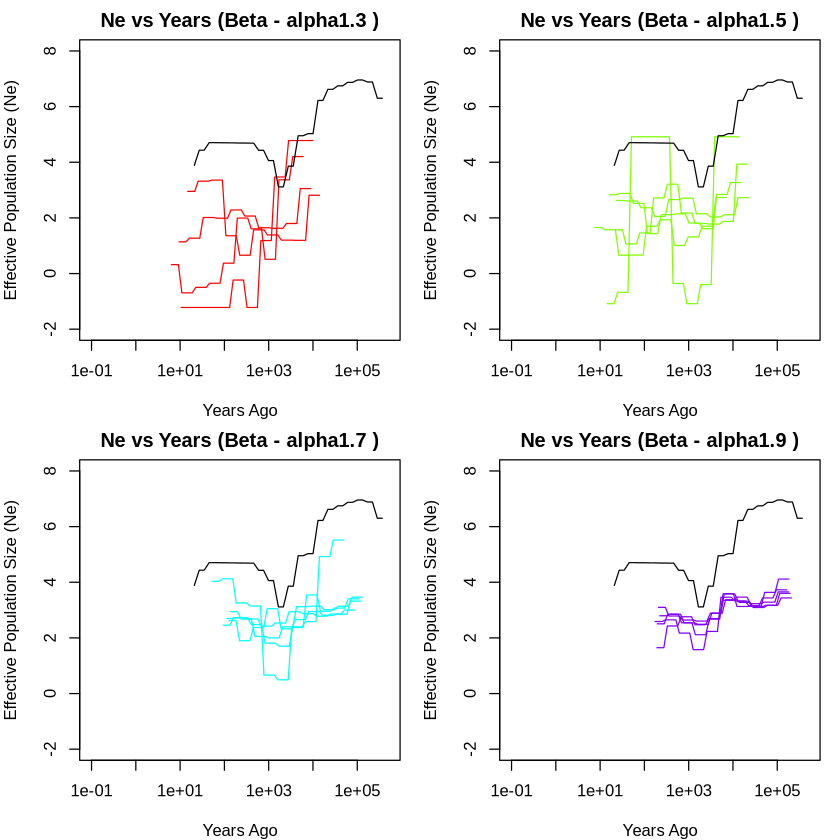

In [23]:
# Define the number of rows and columns for subplots based on the number of alpha values
num_alphas <- length(alpha_values)
rows <- ceiling(sqrt(num_alphas))  # Number of rows for the plot grid
cols <- ceiling(num_alphas / rows) # Number of columns for the plot grid

# Set up layout for multiple subplots
par(mfrow = c(rows, cols), mar = c(4, 4, 2, 1), bg = "white")  # White background for the plots

# Check that alpha_values and colors are compatible
if (length(alpha_values) != length(colors)) {
  stop("Length of alpha_values does not match the length of colors.")
}

# Loop over each alpha value and create individual plots
for (alpha in alpha_values) {
  
  # Set up an empty plot for the current alpha
  plot(NULL, xlim = c(0.1, 500000), ylim = c(-2, 8),
       xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
       main = paste("Ne vs Years (Beta -", alpha, ")"),
       log = "x", col = "black")
  
  # Filter Beta data frames by the current alpha
  beta_lines <- lapply(individual_data_frames[[2]], function(df) {
    if (!is.null(df) && df$alpha_sim[1] == alpha) {  # Ensure df is not NULL
      return(df)
    } else {
      return(NULL)
    }
  })

  beta_lines <- Filter(Negate(is.null), beta_lines)  # Remove NULL entries
  
  # If beta_lines is empty, skip the plot for this alpha
  if (length(beta_lines) > 0) {
    # Plot each line for the current alpha
    for (i in seq_along(beta_lines)) {
      lines(beta_lines[[i]]$years_ago, beta_lines[[i]]$Ne, 
            type = "l", lty = 1, col = colors[which(alpha_values == alpha)])
    }
  } else {
    message("No data found for alpha: ", alpha)
  }

  # Plot the overall demography line in black for each subplot
  lines(demography_data$years_ago, demography_data$Ne, 
        type = "l", lty = 1, col = "black")
}

# Reset layout to default for any further plots
par(mfrow = c(1, 1), bg = "white")


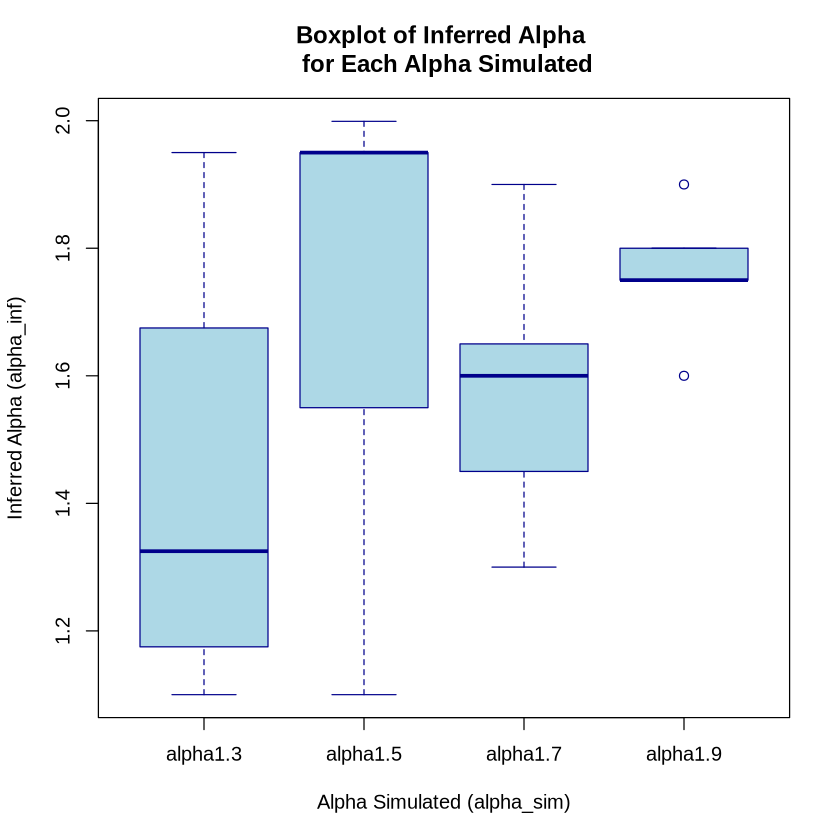

In [24]:
# Initialize a list to store alpha_inf values grouped by alpha_sim
alpha_data <- list()

# Loop through each entry in individual_data_frames to extract alpha_sim and alpha_inf
for (entry in individual_data_frames[[2]]) {
  if (!is.null(entry$alpha_sim) && !is.null(entry$alpha_inf)) {
    alpha_sim <- entry$alpha_sim[1]  # Get the alpha_sim (assuming it’s consistent within each data frame)
    alpha_inf <- entry$alpha_inf[1]  # Get the alpha_inf for this specific simulation
    
    # Append the alpha_inf value to the appropriate alpha_sim group
    if (alpha_sim %in% names(alpha_data)) {
      alpha_data[[alpha_sim]] <- c(alpha_data[[alpha_sim]], alpha_inf)
    } else {
      alpha_data[[alpha_sim]] <- alpha_inf
    }
  }
}

# Convert the list into a data frame suitable for plotting
plot_data <- stack(alpha_data)
names(plot_data) <- c("alpha_inf", "alpha_sim")  # Rename columns for clarity

# Set background color to white
par(bg = "white")

# Create the boxplot
boxplot(alpha_inf ~ alpha_sim, data = plot_data,
        xlab = "Alpha Simulated (alpha_sim)",
        ylab = "Inferred Alpha (alpha_inf)",
        main = paste("Boxplot of Inferred Alpha", "\n", "for Each Alpha Simulated"),
        col = "lightblue", border = "darkblue")



if Ne is underestimated then TMRCAs are underestimated

The TMRCA distribution (waiting time) tends to longer TMRCAs then old population sizes are larger 

m1e-08

In [64]:
rds_files_list[[5]]

[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_beta/m1e-8_free_r/alpha1.3/Beta_bottleneck_rep0_m1e-08_ratio10.0_rs1525225.vcf.rds"
 [2] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_beta/m1e-8_free_r/alpha1.3/Beta_bottleneck_rep1_m1e-08_ratio10.0_rs1525226.vcf.rds"
 [3] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_beta/m1e-8_free_r/alpha1.3/Beta_bottleneck_rep2_m1e-08_ratio10.0_rs1525227.vcf.rds"
 [4] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_beta/m1e-8_free_r/alpha1.3/Beta_bottleneck_rep3_m1e-08_ratio10.0_rs1525228.vcf.rds"
 [5] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_beta/m1e-8_free_r/alpha1.5/Beta_bottleneck_rep0_m1e-08_ratio10.0_rs1525225.vcf.rds"
 [6] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_beta/m1e-8_free_r/alpha1.5/Beta_bottleneck_rep1_m1e-08_ratio10.0_rs1525226.vcf.rds"
 [7] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_beta/m1e-8_free_r/alpha1.5/Beta_bottleneck_rep2_m1e-08_ratio10.0_rs1525227.vcf.rds"
 [8] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_beta/m1e-8_free_r/alpha1.5/Beta_bottleneck_rep3_m1e-08_ratio10.0_rs1525228.vcf.rds"
 [9] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_beta/m1e-8_free_r/alpha1.5/Beta_bottleneck_rep4_m1e-08_ratio10.0_rs1525229.vcf.rds"
[10] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_beta/m1e-8_free_r/alpha1.7/Beta_bottleneck_rep0_m1e-08_ratio10.0_rs1525225.vcf.rds"
[11] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_beta/m1e-8_free_r/alpha1.7/Beta_bottleneck_rep1_m1e-08_ratio10.0_rs1525226.vcf.rds"
[12] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_beta/m1e-8_free_r/alpha1.7/Beta_bottleneck_rep2_m1e-08_ratio10.0_rs1525227.vcf.rds"
[13] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_beta/m1e-8_free_r/alpha1.7/Beta_bottleneck_rep3_m1e-08_ratio10.0_rs1525228.vcf.rds"
[14] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_beta/m1e-8_free_r/alpha1.7/Beta_bottleneck_rep4_m1e-08_ratio10.0_rs1525229.vcf.rds"
[15] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_beta/m1e-8_free_r/alpha1.9/Beta_bottleneck_rep0_m1e-08_ratio10.0_rs1525225.vcf.rds"
[16] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_beta/m1e-8_free_r/alpha1.9/Beta_bottleneck_rep1_m1e-08_ratio10.0_rs1525226.vcf.rds"
[17] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_beta/m1e-8_free_r/alpha1.9/Beta_bottleneck_rep2_m1e-08_ratio10.0_rs1525227.vcf.rds"
[18] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_beta/m1e-8_free_r/alpha1.9/Beta_bottleneck_rep3_m1e-08_ratio10.0_rs1525228.vcf.rds"
[19] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/SMBC_outs/smbc_6haps_beta/m1e-8_free_r/alpha1.9/Beta_bottleneck_rep4_m1e-08_ratio10.0_rs1525229.vcf.rds"

In [50]:
# Constants
mu <- 1e-08
gen_times <-25

# Initialize a list to store individual data frames with hierarchical structure
individual_data_frames <- vector("list", length(rds_files_list))


# Initialize sub-lists for 'kingman' and 'beta' within each main entry
individual_data_frames[[3]] <- list()
  

  # Process 'beta' files
  for (j in seq_along(rds_files_list[[5]])) {
    beta_dir <- rds_files_list[[5]][j]
    #split path
    path_components <- unlist(strsplit(beta_dir, "/"))
    # Extract the second last component
    second_last_component <- path_components[length(path_components) - 1]
    if (file.exists(beta_dir)) {
      data_esmc <- readRDS(beta_dir)  # Read the .rds file

      # Perform calculations
      Ne_t <- data_esmc$Xi
      Ne <- mean(data_esmc$mu / mu)
      alpha<-data_esmc$alpha
      # Calculate years ago and log10 of Ne
      data_esmc$years_ago <- data_esmc$Tc * Ne * gen_times
      data_esmc$Ne <- log10(Ne_t * Ne)
      
      # Create a unique label using both j and file_base_name
      file_base_name <- basename(beta_dir)
      label <- paste0(j, "_",file_base_name)
      # Store the results in a data frame using the unique label
      individual_data_frames[[3]][[label]] <- data.frame(
        years_ago = data_esmc$years_ago,
        Ne = data_esmc$Ne,
        alpha_sim=as.character(second_last_component),
        alpha_inf=alpha
      )
    } else {
      warning(paste("Beta directory does not exist:", beta_dir))
    }
}



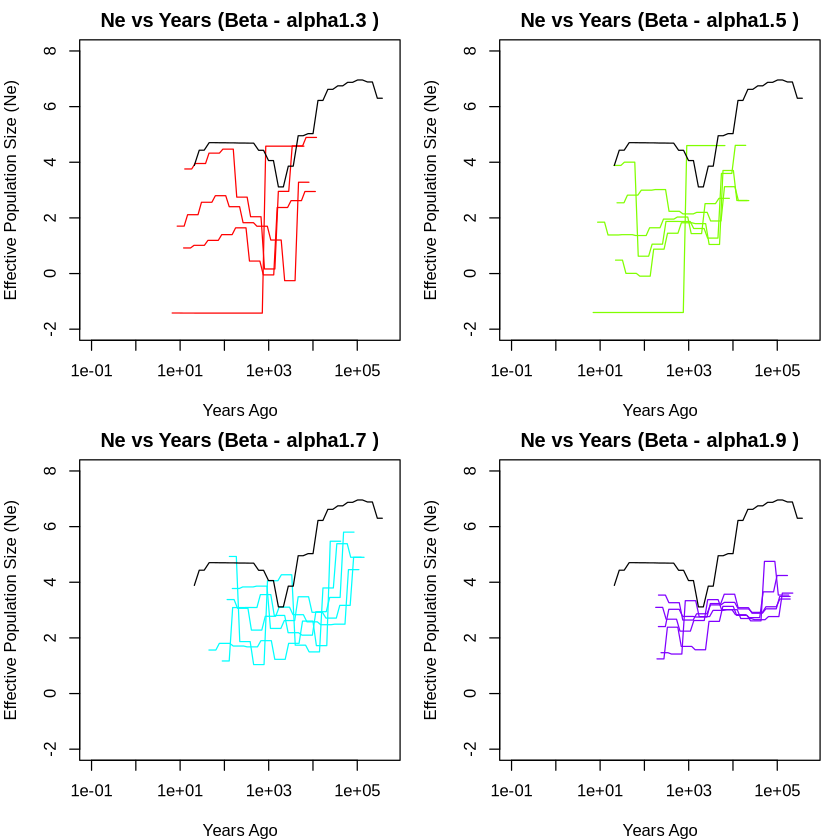

In [51]:
# Define the number of rows and columns for subplots based on the number of alpha values
num_alphas <- length(alpha_values)
rows <- ceiling(sqrt(num_alphas))  # Number of rows for the plot grid
cols <- ceiling(num_alphas / rows) # Number of columns for the plot grid

# Set up layout for multiple subplots
par(mfrow = c(rows, cols), mar = c(4, 4, 2, 1), bg = "white")  # White background for the plots

# Check that alpha_values and colors are compatible
if (length(alpha_values) != length(colors)) {
  stop("Length of alpha_values does not match the length of colors.")
}

# Loop over each alpha value and create individual plots
for (alpha in alpha_values) {
  
  # Set up an empty plot for the current alpha
  plot(NULL, xlim = c(0.1, 500000), ylim = c(-2, 8),
       xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
       main = paste("Ne vs Years (Beta -", alpha, ")"),
       log = "x", col = "black")
  
  # Filter Beta data frames by the current alpha
  beta_lines <- lapply(individual_data_frames[[3]], function(df) {
    if (!is.null(df) && df$alpha_sim[1] == alpha) {  # Ensure df is not NULL
      return(df)
    } else {
      return(NULL)
    }
  })

  beta_lines <- Filter(Negate(is.null), beta_lines)  # Remove NULL entries
  
  # If beta_lines is empty, skip the plot for this alpha
  if (length(beta_lines) > 0) {
    # Plot each line for the current alpha
    for (i in seq_along(beta_lines)) {
      lines(beta_lines[[i]]$years_ago, beta_lines[[i]]$Ne, 
            type = "l", lty = 1, col = colors[which(alpha_values == alpha)])
    }
  } else {
    message("No data found for alpha: ", alpha)
  }

  # Plot the overall demography line in black for each subplot
  lines(demography_data$years_ago, demography_data$Ne, 
        type = "l", lty = 1, col = "black")
}

# Reset layout to default for any further plots
par(mfrow = c(1, 1), bg = "white")


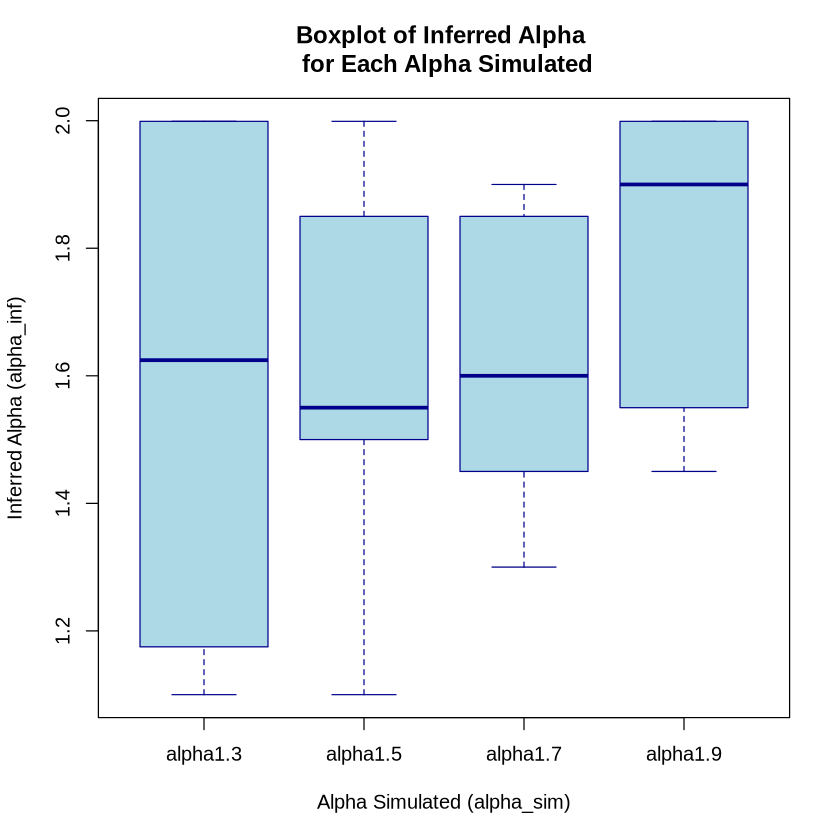

In [52]:
# Initialize a list to store alpha_inf values grouped by alpha_sim
alpha_data <- list()

# Loop through each entry in individual_data_frames to extract alpha_sim and alpha_inf
for (entry in individual_data_frames[[3]]) {
  if (!is.null(entry$alpha_sim) && !is.null(entry$alpha_inf)) {
    alpha_sim <- entry$alpha_sim[1]  # Get the alpha_sim (assuming it’s consistent within each data frame)
    alpha_inf <- entry$alpha_inf[1]  # Get the alpha_inf for this specific simulation
    
    # Append the alpha_inf value to the appropriate alpha_sim group
    if (alpha_sim %in% names(alpha_data)) {
      alpha_data[[alpha_sim]] <- c(alpha_data[[alpha_sim]], alpha_inf)
    } else {
      alpha_data[[alpha_sim]] <- alpha_inf
    }
  }
}

# Convert the list into a data frame suitable for plotting
plot_data <- stack(alpha_data)
names(plot_data) <- c("alpha_inf", "alpha_sim")  # Rename columns for clarity

# Set background color to white
par(bg = "white")

# Create the boxplot
boxplot(alpha_inf ~ alpha_sim, data = plot_data,
        xlab = "Alpha Simulated (alpha_sim)",
        ylab = "Inferred Alpha (alpha_inf)",
        main = paste("Boxplot of Inferred Alpha", "\n", "for Each Alpha Simulated"),
        col = "lightblue", border = "darkblue")




1e-08

In [40]:
# Constants
mu <- 1e-8
gen_times <-25

# Initialize a list to store individual data frames with hierarchical structure
individual_data_frames <- vector("list", length(rds_files_list))


# Initialize sub-lists for 'kingman' and 'beta' within each main entry
individual_data_frames[[4]] <- list()
  

  # Process 'beta' files
  for (j in seq_along(rds_files_list[[6]])) {
    beta_dir <- rds_files_list[[6]][j]
    #split path
    path_components <- unlist(strsplit(beta_dir, "/"))
    # Extract the second last component
    second_last_component <- path_components[length(path_components) - 1]
    if (file.exists(beta_dir)) {
      data_esmc <- readRDS(beta_dir)  # Read the .rds file

      # Perform calculations
      Ne_t <- data_esmc$Xi
      Ne <- mean(data_esmc$mu / mu)
      alpha<-data_esmc$alpha
      # Calculate years ago and log10 of Ne
      data_esmc$years_ago <- data_esmc$Tc * Ne * gen_times
      data_esmc$Ne <- log10(Ne_t * Ne)
      
      # Create a unique label using both j and file_base_name
      file_base_name <- basename(beta_dir)
      label <- paste0(j, "_",file_base_name)
      # Store the results in a data frame using the unique label
      individual_data_frames[[4]][[label]] <- data.frame(
        years_ago = data_esmc$years_ago,
        Ne = data_esmc$Ne,
        alpha_sim=as.character(second_last_component),
        alpha_inf=alpha
      )
    } else {
      warning(paste("Beta directory does not exist:", beta_dir))
    }
}



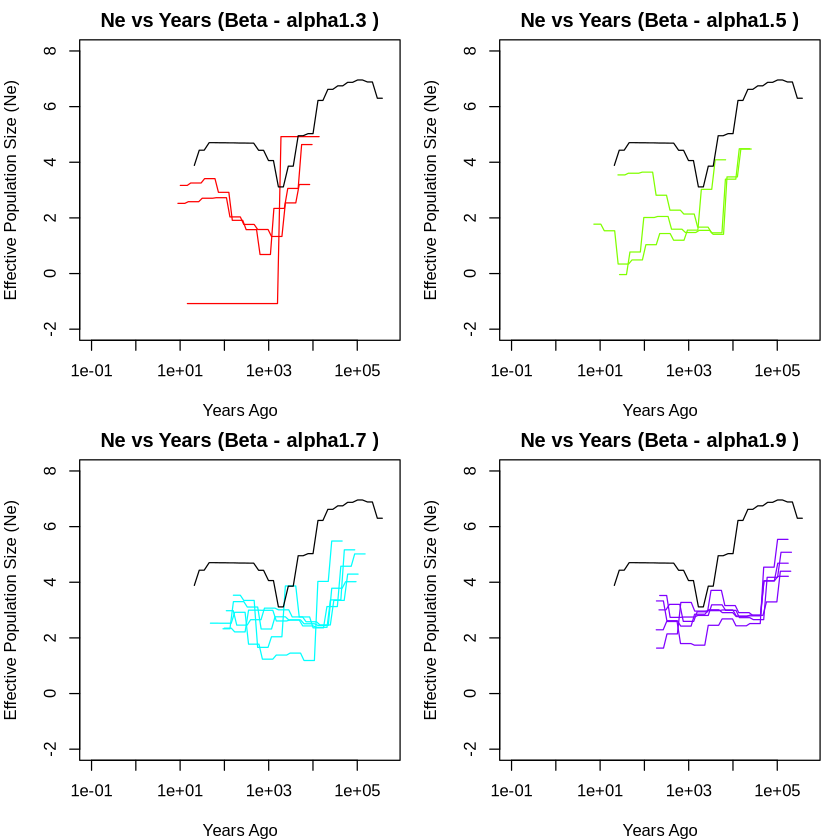

In [41]:
# Define the number of rows and columns for subplots based on the number of alpha values
num_alphas <- length(alpha_values)
rows <- ceiling(sqrt(num_alphas))  # Number of rows for the plot grid
cols <- ceiling(num_alphas / rows) # Number of columns for the plot grid

# Set up layout for multiple subplots
par(mfrow = c(rows, cols), mar = c(4, 4, 2, 1), bg = "white")  # White background for the plots

# Check that alpha_values and colors are compatible
if (length(alpha_values) != length(colors)) {
  stop("Length of alpha_values does not match the length of colors.")
}

# Loop over each alpha value and create individual plots
for (alpha in alpha_values) {
  
  # Set up an empty plot for the current alpha
  plot(NULL, xlim = c(0.1, 500000), ylim = c(-2, 8),
       xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
       main = paste("Ne vs Years (Beta -", alpha, ")"),
       log = "x", col = "black")
  
  # Filter Beta data frames by the current alpha
  beta_lines <- lapply(individual_data_frames[[4]], function(df) {
    if (!is.null(df) && df$alpha_sim[1] == alpha) {  # Ensure df is not NULL
      return(df)
    } else {
      return(NULL)
    }
  })

  beta_lines <- Filter(Negate(is.null), beta_lines)  # Remove NULL entries
  
  # If beta_lines is empty, skip the plot for this alpha
  if (length(beta_lines) > 0) {
    # Plot each line for the current alpha
    for (i in seq_along(beta_lines)) {
      lines(beta_lines[[i]]$years_ago, beta_lines[[i]]$Ne, 
            type = "l", lty = 1, col = colors[which(alpha_values == alpha)])
    }
  } else {
    message("No data found for alpha: ", alpha)
  }

  # Plot the overall demography line in black for each subplot
  lines(demography_data$years_ago, demography_data$Ne, 
        type = "l", lty = 1, col = "black")
}

# Reset layout to default for any further plots
par(mfrow = c(1, 1), bg = "white")


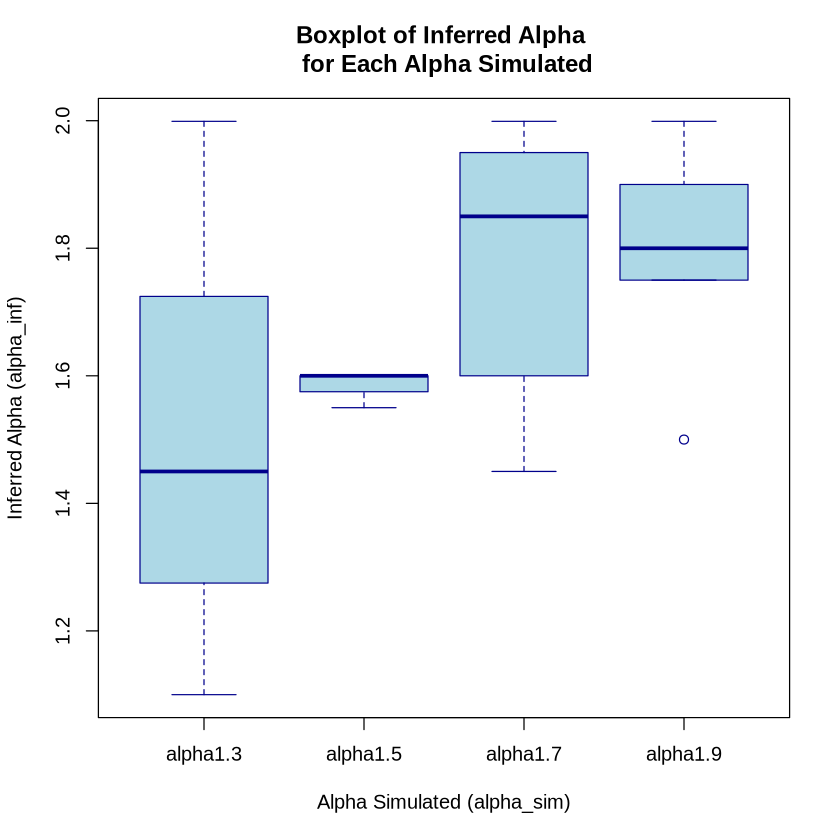

In [42]:
# Initialize a list to store alpha_inf values grouped by alpha_sim
alpha_data <- list()

# Loop through each entry in individual_data_frames to extract alpha_sim and alpha_inf
for (entry in individual_data_frames[[4]]) {
  if (!is.null(entry$alpha_sim) && !is.null(entry$alpha_inf)) {
    alpha_sim <- entry$alpha_sim[1]  # Get the alpha_sim (assuming it’s consistent within each data frame)
    alpha_inf <- entry$alpha_inf[1]  # Get the alpha_inf for this specific simulation
    
    # Append the alpha_inf value to the appropriate alpha_sim group
    if (alpha_sim %in% names(alpha_data)) {
      alpha_data[[alpha_sim]] <- c(alpha_data[[alpha_sim]], alpha_inf)
    } else {
      alpha_data[[alpha_sim]] <- alpha_inf
    }
  }
}

# Convert the list into a data frame suitable for plotting
plot_data <- stack(alpha_data)
names(plot_data) <- c("alpha_inf", "alpha_sim")  # Rename columns for clarity

# Set background color to white
par(bg = "white")

# Create the boxplot
boxplot(alpha_inf ~ alpha_sim, data = plot_data,
        xlab = "Alpha Simulated (alpha_sim)",
        ylab = "Inferred Alpha (alpha_inf)",
        main = paste("Boxplot of Inferred Alpha", "\n", "for Each Alpha Simulated"),
        col = "lightblue", border = "darkblue")



1e-10

In [58]:
# Constants
mu <- 1e-10
gen_times <-25

# Initialize a list to store individual data frames with hierarchical structure
individual_data_frames <- vector("list", length(rds_files_list))


# Initialize sub-lists for 'kingman' and 'beta' within each main entry
individual_data_frames[[5]] <- list()
  

  # Process 'beta' files
  for (j in seq_along(rds_files_list[[1]])) {
    beta_dir <- rds_files_list[[1]][j]
    #split path
    path_components <- unlist(strsplit(beta_dir, "/"))
    # Extract the second last component
    second_last_component <- path_components[length(path_components) - 1]
    if (file.exists(beta_dir)) {
      data_esmc <- readRDS(beta_dir)  # Read the .rds file

      # Perform calculations
      Ne_t <- data_esmc$Xi
      Ne <- mean(data_esmc$mu / mu)
      alpha<-data_esmc$alpha
      rho_mu<-data_esmc$rho/data_esmc$mu
      # Calculate years ago and log10 of Ne
      data_esmc$years_ago <- data_esmc$Tc * Ne * gen_times
      data_esmc$Ne <- log10(Ne_t * Ne)
      
      # Create a unique label using both j and file_base_name
      file_base_name <- basename(beta_dir)
      label <- paste0(j, "_",file_base_name)
      # Store the results in a data frame using the unique label
      individual_data_frames[[5]][[label]] <- data.frame(
        years_ago = data_esmc$years_ago,
        Ne = data_esmc$Ne,
        alpha_sim=as.character(second_last_component),
        alpha_inf=alpha,
        r_mu=rho_mu
      )
    } else {
      warning(paste("Beta directory does not exist:", beta_dir))
    }
}



No data found for alpha: alpha1.3



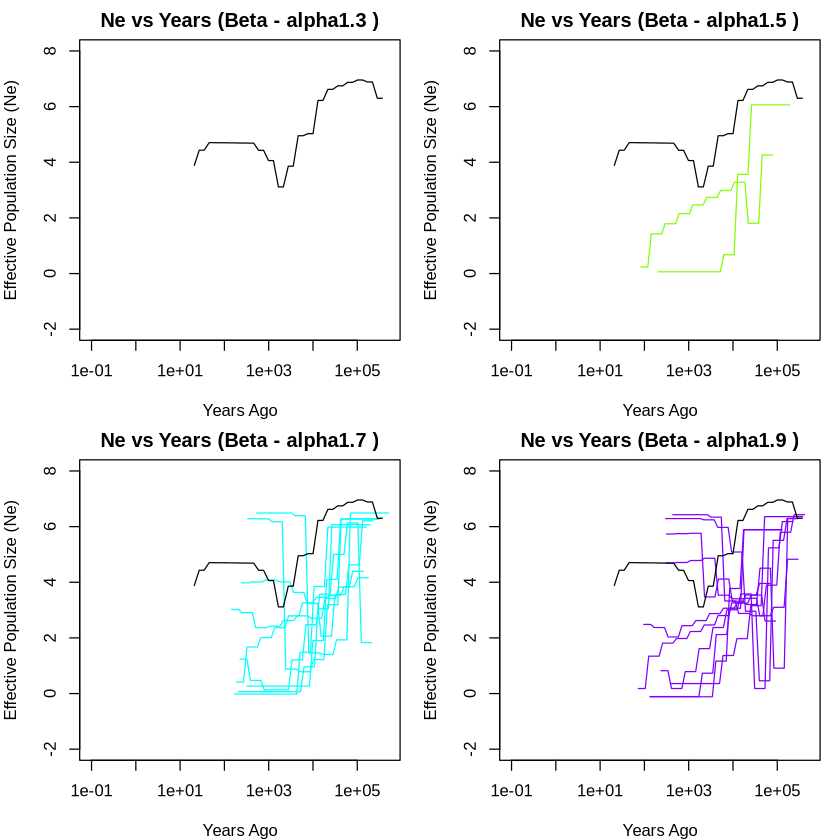

In [59]:
# Define the number of rows and columns for subplots based on the number of alpha values
num_alphas <- length(alpha_values)
rows <- ceiling(sqrt(num_alphas))  # Number of rows for the plot grid
cols <- ceiling(num_alphas / rows) # Number of columns for the plot grid

# Set up layout for multiple subplots
par(mfrow = c(rows, cols), mar = c(4, 4, 2, 1), bg = "white")  # White background for the plots

# Check that alpha_values and colors are compatible
if (length(alpha_values) != length(colors)) {
  stop("Length of alpha_values does not match the length of colors.")
}

# Loop over each alpha value and create individual plots
for (alpha in alpha_values) {
  
  # Set up an empty plot for the current alpha
  plot(NULL, xlim = c(0.1, 500000), ylim = c(-2, 8),
       xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
       main = paste("Ne vs Years (Beta -", alpha, ")"),
       log = "x", col = "black")
  
  # Filter Beta data frames by the current alpha
  beta_lines <- lapply(individual_data_frames[[5]], function(df) {
    if (!is.null(df) && df$alpha_sim[1] == alpha) {  # Ensure df is not NULL
      return(df)
    } else {
      return(NULL)
    }
  })

  beta_lines <- Filter(Negate(is.null), beta_lines)  # Remove NULL entries
  
  # If beta_lines is empty, skip the plot for this alpha
  if (length(beta_lines) > 0) {
    # Plot each line for the current alpha
    for (i in seq_along(beta_lines)) {
      lines(beta_lines[[i]]$years_ago, beta_lines[[i]]$Ne, 
            type = "l", lty = 1, col = colors[which(alpha_values == alpha)])
    }
  } else {
    message("No data found for alpha: ", alpha)
  }

  # Plot the overall demography line in black for each subplot
  lines(demography_data$years_ago, demography_data$Ne, 
        type = "l", lty = 1, col = "black")
}

# Reset layout to default for any further plots
par(mfrow = c(1, 1), bg = "white")



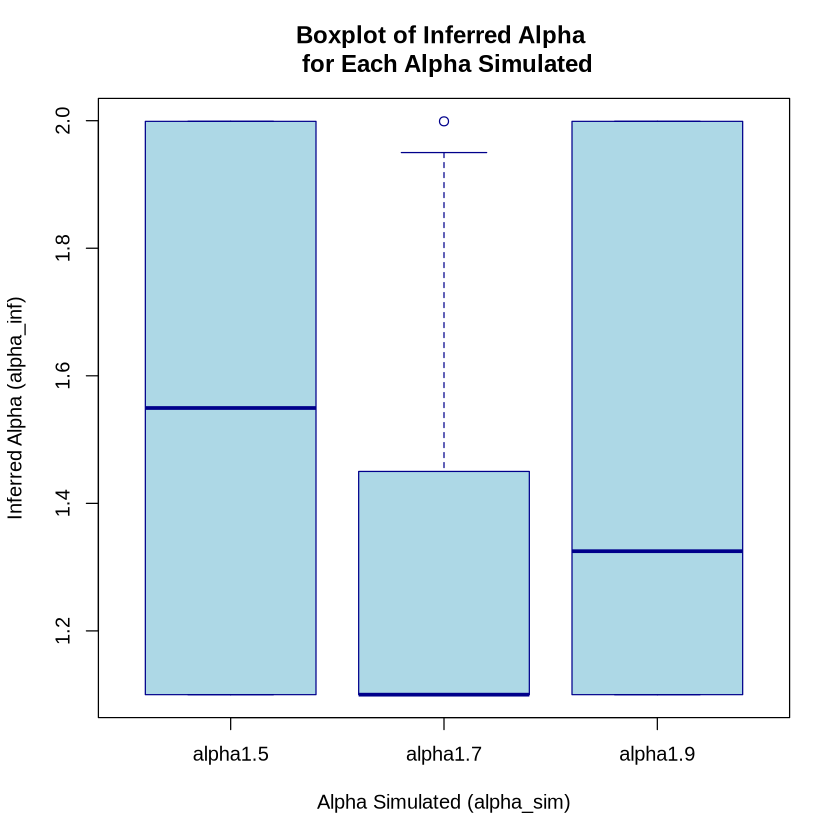

In [60]:
# Initialize a list to store alpha_inf values grouped by alpha_sim
alpha_data <- list()

# Loop through each entry in individual_data_frames to extract alpha_sim and alpha_inf
for (entry in individual_data_frames[[5]]) {
  if (!is.null(entry$alpha_sim) && !is.null(entry$alpha_inf)) {
    alpha_sim <- entry$alpha_sim[1]  # Get the alpha_sim (assuming it’s consistent within each data frame)
    alpha_inf <- entry$alpha_inf[1]  # Get the alpha_inf for this specific simulation
    
    # Append the alpha_inf value to the appropriate alpha_sim group
    if (alpha_sim %in% names(alpha_data)) {
      alpha_data[[alpha_sim]] <- c(alpha_data[[alpha_sim]], alpha_inf)
    } else {
      alpha_data[[alpha_sim]] <- alpha_inf
    }
  }
}

# Convert the list into a data frame suitable for plotting
plot_data <- stack(alpha_data)
names(plot_data) <- c("alpha_inf", "alpha_sim")  # Rename columns for clarity

# Set background color to white
par(bg = "white")

# Create the boxplot
boxplot(alpha_inf ~ alpha_sim, data = plot_data,
        xlab = "Alpha Simulated (alpha_sim)",
        ylab = "Inferred Alpha (alpha_inf)",
        main = paste("Boxplot of Inferred Alpha", "\n", "for Each Alpha Simulated"),
        col = "lightblue", border = "darkblue")



In [63]:
individual_data_frames[[5]]

years_ago,Ne,alpha_sim,alpha_inf,r_mu
<dbl>,<dbl>,<chr>,<dbl>,<dbl>
0.0000,0.06267212,alpha1.5,1.1,10
201.9498,0.06267212,alpha1.5,1.1,10
241.8298,0.06267212,alpha1.5,1.1,10
289.5851,0.06267212,alpha1.5,1.1,10
346.7709,0.06267212,alpha1.5,1.1,10
415.2494,0.06267212,alpha1.5,1.1,10
497.2507,0.06267212,alpha1.5,1.1,10
595.4452,0.06267212,alpha1.5,1.1,10
713.0306,0.06267212,alpha1.5,1.1,10


In [61]:
# Initialize a list to store alpha_inf values grouped by alpha_sim
rho_mu_data <- list()

# Loop through each entry in individual_data_frames to extract alpha_sim and alpha_inf
for (entry in individual_data_frames[[5]]) {
  if (!is.null(entry$r_mu)) {
    rho_mu_data<- entry$r_mu  # Get the alpha_sim (assuming it’s consistent within each data frame)
  }
}

# Assume rho_mu_data is a named list with each element being numeric values for an alpha_sim
# Convert it to a data frame for plotting
plot_data <- stack(rho_mu_data)  # Converts list to data frame with columns 'values' and 'ind'
plot_data

ERROR: Error in data.frame(values = unlist(unname(x)), ind, stringsAsFactors = FALSE): arguments imply differing number of rows: 40, 0


In [62]:
rho_mu_data

[1] 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10
[26] 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10

In [55]:

# Rename columns for clarity
colnames(plot_data) <- c("r_mu", "alpha_sim")

# Plot the boxplot
boxplot(r_mu ~ alpha_sim, data = plot_data,
        xlab = "Alpha Simulated (alpha_sim)",
        ylab = "Inferred r/m (r_mu)",
        main = "Boxplot of Inferred r/m for Each Alpha Simulated",
        col = "lightblue", border = "darkblue")



ERROR: Error: object 'rho_mu_data' not found
